In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib
import warnings
warnings.filterwarnings("ignore")

In [28]:
df = pd.read_csv("../data/processed/processed_country_volatility.csv")
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values(["CountryName", "Date"]).reset_index(drop=True)

df.head()

,CountryName,Date,MonthlyChangeSA,lag_1,lag_2,lag_3,lag_6,lag_12,rolling_mean_3,rolling_std_3,rolling_mean_6,rolling_std_6,rolling_mean_12,rolling_std_12,month,year,quarter,month_sin,month_cos
0,Afghanistan,2021-10-01,1.0,-0.5,3.5,3.0,-2.0,0.5,1.333333,2.020726,1.166667,1.693123,0.458333,1.529384,10,2021,4,-8.660254e-01,0.500000
1,Afghanistan,2021-11-01,0.5,1.0,-0.5,3.5,0.0,1.0,0.333333,0.763763,1.250000,1.635543,0.416667,1.520068,11,2021,4,-5.000000e-01,0.866025
2,Afghanistan,2021-12-01,4.5,0.5,1.0,-0.5,0.0,-0.5,2.000000,2.179449,2.000000,1.949359,0.833333,1.886957,12,2021,4,-2.449294e-16,1.000000
3,Afghanistan,2022-01-01,0.0,4.5,0.5,1.0,3.0,0.0,1.666667,2.466441,1.500000,2.024846,0.833333,1.886957,1,2022,1,5.000000e-01,0.866025
4,Afghanistan,2022-02-01,-1.5,0.0,4.5,0.5,3.5,0.5,1.000000,3.122499,0.666667,2.065591,0.666667,2.003784,2,2022,1,8.660254e-01,0.500000


In [29]:
# remove leakage-prone columns
leakage_cols = [
    "rolling_mean_3",
    "rolling_mean_6",
    "rolling_mean_12",
    "rolling_std_3",
    "rolling_std_6",
    "rolling_std_12"
]

df = df.drop(columns=leakage_cols)

df.head()

,CountryName,Date,MonthlyChangeSA,lag_1,lag_2,lag_3,lag_6,lag_12,month,year,quarter,month_sin,month_cos
0,Afghanistan,2021-10-01,1.0,-0.5,3.5,3.0,-2.0,0.5,10,2021,4,-8.660254e-01,0.500000
1,Afghanistan,2021-11-01,0.5,1.0,-0.5,3.5,0.0,1.0,11,2021,4,-5.000000e-01,0.866025
2,Afghanistan,2021-12-01,4.5,0.5,1.0,-0.5,0.0,-0.5,12,2021,4,-2.449294e-16,1.000000
3,Afghanistan,2022-01-01,0.0,4.5,0.5,1.0,3.0,0.0,1,2022,1,5.000000e-01,0.866025
4,Afghanistan,2022-02-01,-1.5,0.0,4.5,0.5,3.5,0.5,2,2022,1,8.660254e-01,0.500000


In [30]:
cutoff_date = df["Date"].max() - pd.DateOffset(months=6)

train_df = df[df["Date"] <= cutoff_date]
test_df = df[df["Date"] > cutoff_date]

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Train max date:", train_df["Date"].max())
print("Test min date:", test_df["Date"].min())

Train shape: (1850, 13)
Test shape: (280, 13)
Train max date: 2024-06-01 00:00:00
Test min date: 2024-07-01 00:00:00


In [31]:
drop_cols = ["Date", "CountryName", "MonthlyChangeSA"]

feature_cols = [col for col in df.columns if col not in drop_cols]

X_train = train_df[feature_cols]
y_train = train_df["MonthlyChangeSA"]

X_test = test_df[feature_cols]
y_test = test_df["MonthlyChangeSA"]

In [32]:
baseline_model = LinearRegression()

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

In [33]:
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"{model_name}")
    print("-" * 40)
    print("MAE :", round(mae, 4))
    print("RMSE:", round(rmse, 4))
    print("R²  :", round(r2, 4))

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [34]:
baseline_results = evaluate_model(
    y_test,
    baseline_pred,
    "Linear Regression"
)

baseline_results

Linear Regression
----------------------------------------
MAE : 3.6202
RMSE: 5.8617
R²  : 0.4072


{'Model': 'Linear Regression',
 'MAE': 3.6202017276920033,
 'RMSE': np.float64(5.861653615676181),
 'R2': 0.40724122005337493}

In [35]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [36]:
rf_results = evaluate_model(
    y_test,
    rf_pred,
    "Random Forest"
)

rf_results

Random Forest
----------------------------------------
MAE : 3.7097
RMSE: 6.8302
R²  : 0.1952


{'Model': 'Random Forest',
 'MAE': 3.709746447299316,
 'RMSE': np.float64(6.830151257697593),
 'R2': 0.1951807851480506}

In [37]:
!pip install xgboost

In [38]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

In [39]:
xgb_results = evaluate_model(
    y_test,
    xgb_pred,
    "XGBoost"
)

xgb_results

XGBoost
----------------------------------------
MAE : 4.2085
RMSE: 7.4699
R²  : 0.0374


{'Model': 'XGBoost',
 'MAE': 4.20853444456023,
 'RMSE': np.float64(7.469906465850942),
 'R2': 0.037350873225064474}

In [ ]:
!pip install lightgbm

^C


In [ ]:
from lightgbm import LGBMRegressor

lgbm_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

lgbm_model.fit(X_train, y_train)

lgbm_pred = lgbm_model.predict(X_test)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000646 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 893
[LightGBM] [Info] Number of data points in the train set: 1850, number of used features: 10
[LightGBM] [Info] Start training from score 1.029689


In [ ]:
lgbm_results = evaluate_model(
    y_test,
    lgbm_pred,
    "LightGBM"
)

lgbm_results

LightGBM
----------------------------------------
MAE : 3.992
RMSE: 6.9048
R²  : 0.1775


{'Model': 'LightGBM',
 'MAE': 3.99200589840991,
 'RMSE': np.float64(6.904802771774898),
 'R2': 0.17749177528093452}

In [ ]:
results_df = pd.DataFrame([
    baseline_results,
    rf_results,
    xgb_results,
    lgbm_results
])

results_df = results_df.sort_values("RMSE")

results_df

,Model,MAE,RMSE,R2
0,Linear Regression,3.620202,5.861654,0.407241
1,Random Forest,3.709746,6.830151,0.195181
3,LightGBM,3.992006,6.904803,0.177492
2,XGBoost,4.208534,7.469906,0.037351


In [ ]:
importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": baseline_model.coef_
})

importance_df["AbsCoefficient"] = importance_df["Coefficient"].abs()

importance_df = importance_df.sort_values(
    "AbsCoefficient",
    ascending=False
)

importance_df.head(15)

,Feature,Coefficient,AbsCoefficient
6,year,-0.639419,0.639419
0,lag_1,0.442598,0.442598
9,month_cos,0.291905,0.291905
1,lag_2,0.107559,0.107559
7,quarter,-0.093141,0.093141
2,lag_3,0.082405,0.082405
5,month,-0.062125,0.062125
4,lag_12,-0.031780,0.031780
8,month_sin,0.030854,0.030854
3,lag_6,0.026591,0.026591


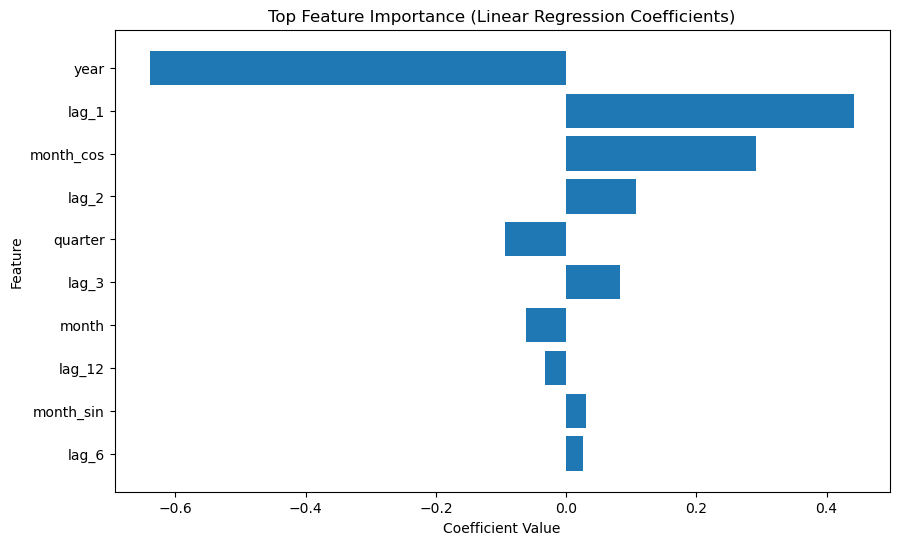

In [ ]:
plt.figure(figsize=(10, 6))

top_features = importance_df.head(15)

plt.barh(top_features["Feature"], top_features["Coefficient"])
plt.gca().invert_yaxis()

plt.title("Top Feature Importance (Linear Regression Coefficients)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.show()

In [ ]:
country_name = "India"   # change to any country from dataset

country_df = df[df["CountryName"] == country_name].copy()
country_df = country_df.sort_values("Date").reset_index(drop=True)

country_df.tail()

,CountryName,Date,MonthlyChangeSA,lag_1,lag_2,lag_3,lag_6,lag_12,month,year,quarter,month_sin,month_cos
34,India,2024-08-01,-1.666667,-0.333333,-0.333333,-0.333333,-1.333333,0.666667,8,2024,3,-8.660254e-01,-5.000000e-01
35,India,2024-09-01,-1.666667,-1.666667,-0.333333,-0.333333,-1.333333,0.666667,9,2024,3,-1.000000e+00,-1.836970e-16
36,India,2024-10-01,-0.666667,-1.666667,-1.666667,-0.333333,0.000000,0.666667,10,2024,4,-8.660254e-01,5.000000e-01
37,India,2024-11-01,-0.666667,-0.666667,-1.666667,-1.666667,-0.333333,0.666667,11,2024,4,-5.000000e-01,8.660254e-01
38,India,2024-12-01,-0.666667,-0.666667,-0.666667,-1.666667,-0.333333,0.666667,12,2024,4,-2.449294e-16,1.000000e+00


In [ ]:
last_row = country_df.iloc[-1].copy()

future_dates = pd.date_range(
    start=last_row["Date"] + pd.DateOffset(months=1),
    periods=6,
    freq="MS"
)

future_predictions = []

In [ ]:
lag_values = {
    "lag_1": last_row["lag_1"],
    "lag_2": last_row["lag_2"],
    "lag_3": last_row["lag_3"],
    "lag_6": last_row["lag_6"],
    "lag_12": last_row["lag_12"]
}

for future_date in future_dates:
    
    month = future_date.month
    year = future_date.year
    quarter = future_date.quarter

    input_row = pd.DataFrame([{
        "lag_1": lag_values["lag_1"],
        "lag_2": lag_values["lag_2"],
        "lag_3": lag_values["lag_3"],
        "lag_6": lag_values["lag_6"],
        "lag_12": lag_values["lag_12"],
        "month": month,
        "year": year,
        "quarter": quarter,
        "month_sin": np.sin(2 * np.pi * month / 12),
        "month_cos": np.cos(2 * np.pi * month / 12)
    }])

    pred = baseline_model.predict(input_row)[0]

    future_predictions.append({
        "Date": future_date,
        "PredictedMonthlyChangeSA": pred
    })

    # update lag values recursively
    lag_values["lag_12"] = lag_values["lag_6"]
    lag_values["lag_6"] = lag_values["lag_3"]
    lag_values["lag_3"] = lag_values["lag_2"]
    lag_values["lag_2"] = lag_values["lag_1"]
    lag_values["lag_1"] = pred

In [ ]:
forecast_df = pd.DataFrame(future_predictions)

forecast_df

,Date,PredictedMonthlyChangeSA
0,2025-01-01,-1.071410
1,2025-02-01,-1.329495
2,2025-03-01,-1.622236
3,2025-04-01,-2.150046
4,2025-05-01,-2.627434
5,2025-06-01,-3.030278


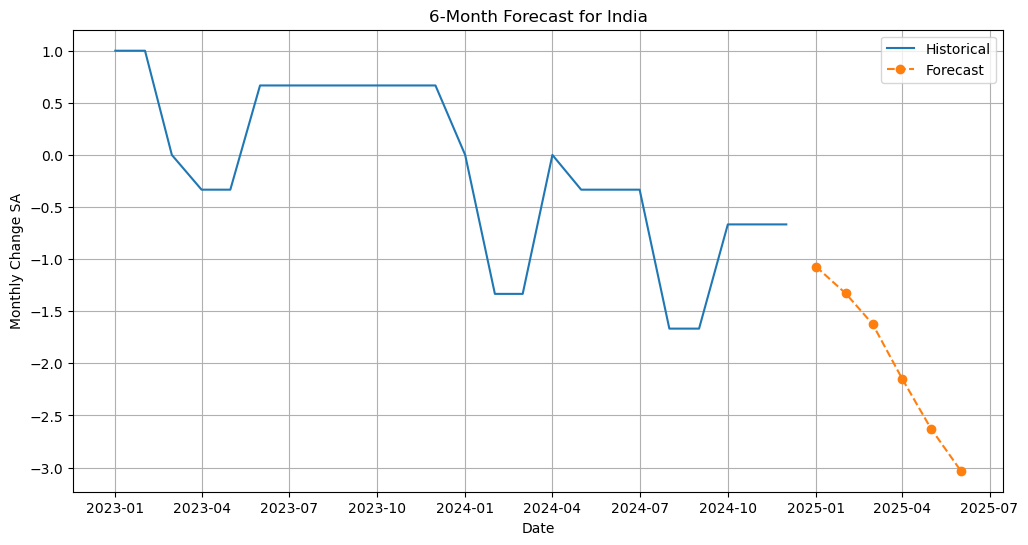

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    country_df["Date"].tail(24),
    country_df["MonthlyChangeSA"].tail(24),
    label="Historical"
)

plt.plot(
    forecast_df["Date"],
    forecast_df["PredictedMonthlyChangeSA"],
    marker="o",
    linestyle="--",
    label="Forecast"
)

plt.title(f"6-Month Forecast for {country_name}")
plt.xlabel("Date")
plt.ylabel("Monthly Change SA")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(baseline_model, "../models/linear_regression.pkl")
joblib.dump(feature_cols, "../models/feature_columns.pkl")

['../models/feature_columns.pkl']